In [4]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt


In [21]:
wf_path = r"M:\analysis\Axel_Bisi\data\AB150\AB150_20241219_144646\Ephys\catgt_AB150_g0\AB150_g0_imec0\kilosort2\cwaves\mean_waveforms.npy"
wf_arr = np.load(wf_path)
print(wf_arr.shape)
wf_metrics_path = r"M:\analysis\Axel_Bisi\data\AB150\AB150_20241219_144646\Ephys\catgt_AB150_g0\AB150_g0_imec0\kilosort2\cwaves\waveform_metrics.csv"
wf_metrics_df = pd.read_csv(wf_metrics_path)
print(len(wf_metrics_df))

chan_map = r"M:\analysis\Axel_Bisi\data\AB150\AB150_20241219_144646\Ephys\catgt_AB150_g0\AB150_g0_imec0\kilosort2\channel_map.npy"
chan_map = np.load(chan_map)
print('chan map', chan_map.shape)

cluster_info = r"M:\analysis\Axel_Bisi\data\AB150\AB150_20241219_144646\Ephys\catgt_AB150_g0\AB150_g0_imec0\kilosort2\cluster_info.tsv"
cluster_info_df = pd.read_csv(cluster_info, sep='\t')
cluster_info_df.tail(5)

(528, 385, 82)
528
chan map (333, 1)


,cluster_id,Amplitude,ContamPct,KSLabel,SNR,amp,bc_unitType,ch,depth,fr,...,n_troughs,peak_1_to_peak_2,peak_2_to_trough,peak_main_to_trough,percentage_spikes_missing,presence_ratio,sh,spatial_decay_slope,waveform_duration,wv_baseline_flatness
523,537,24.0,780.0,mua,58.339572,1.792407,NON-SOMA,338,3400.0,0.058698,...,1.0,0.0,0.268658,2.359312,32.642361,0.982301,0,0.157702,733.333333,0.098574
524,538,24.3,0.0,mua,31.569328,1.880688,NON-SOMA,338,3400.0,0.025974,...,1.0,0.0,0.255597,2.645484,45.812626,0.787611,0,0.119156,733.333333,0.083384
525,539,50.4,0.8,good,35.131317,4.126157,GOOD,112,1140.0,10.469887,...,1.0,0.0,0.369581,0.369581,0.168774,1.000000,0,0.029630,633.333333,0.040180
526,540,29.5,2.5,good,54.524397,2.652314,GOOD,254,2560.0,4.782092,...,1.0,0.0,0.384147,0.384147,11.477323,1.000000,0,0.034484,666.666667,0.040669
527,541,48.9,97.5,mua,33.839367,2.746054,MUA,254,2560.0,0.087019,...,1.0,0.0,0.256827,0.256827,6.287903,0.955752,0,0.020325,600.000000,0.020750


Cluster ID: 50, Peak Channel WF: 51 - 'Peak Channel INFO: 51
Peak channel after WF metrics channel mapping: 51 into 55
Peak channel after KS cluster_info channel mapping: 51 into 51


<Figure size 640x480 with 0 Axes>

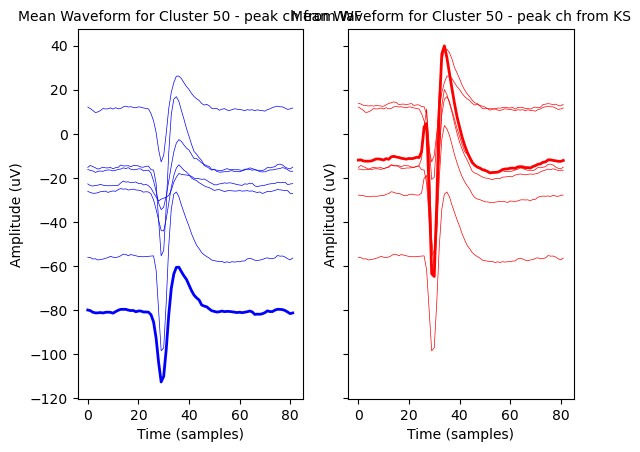

(384,)
(385,)


In [25]:
cluster_id = 50
peak_channel_wf = int(wf_metrics_df[wf_metrics_df.cluster_id==cluster_id]['peak_channel'].values)
peak_channel_cluster_info = int(cluster_info_df[cluster_info_df.cluster_id==cluster_id]['ch'].values)
print(f"Cluster ID: {cluster_id}, Peak Channel WF: {peak_channel_wf} - 'Peak Channel INFO: {peak_channel_cluster_info}")
peak_channel_wf_mapped = chan_map[peak_channel_wf][0]
peak_channel_cluster_info_mapped = chan_map[peak_channel_cluster_info][0]
peak_channel_cluster_info_mapped = peak_channel_cluster_info
print('Peak channel after WF metrics channel mapping:', peak_channel_wf, 'into', peak_channel_wf_mapped)
print('Peak channel after KS cluster_info channel mapping:', peak_channel_cluster_info, 'into', peak_channel_cluster_info_mapped)

plt.figure()
fig, axs = plt.subplots(1,2,sharey=True)
#plt.plot(wf_arr[cluster_id, peak_channel_wf, :], label='mean wf - peak',c='b',lw=2,ls='--')
axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped, :], label='mean wf - peak - mapped',c='b',lw=2)
axs[0]
#plt.plot(wf_arr[cluster_id, peak_channel_cluster_info, :], label='template info KS - peak', c='r',lw=2,ls='--')
axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped, :], label='template info KS - peak - mapped', c='r',lw=2)
show_neigh = True
if show_neigh:
    axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped+1, :],c='b',lw=0.5)
    axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped+2, :],c='b',lw=0.5)
    axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped-1, :],c='b',lw=0.5)
    axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped-2, :],c='b',lw=0.5)
    axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped-3, :],c='b',lw=0.5)
    axs[0].plot(wf_arr[cluster_id, peak_channel_wf_mapped+3, :],c='b',lw=0.5)


    axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped+1, :],c='r',lw=0.5)
    axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped+2, :],c='r',lw=0.5)
    axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped-1, :],c='r',lw=0.5)
    axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped-2, :],c='r',lw=0.5)
    axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped-3, :],c='r',lw=0.5)
    axs[1].plot(wf_arr[cluster_id, peak_channel_cluster_info_mapped+3, :],c='r',lw=0.5)

axs[0].set_title(f"Mean Waveform for Cluster {cluster_id} - peak ch from WF", fontsize=10)
axs[1].set_title(f"Mean Waveform for Cluster {cluster_id} - peak ch from KS", fontsize=10)
for ax in axs.flat:
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Amplitude (uV)")
#plt.legend()
plt.show()

n_clusters = wf_arr.shape[0]
n_channels = wf_arr.shape[1]
n_time_bins = wf_arr.shape[2]

n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))
cols_pos = [0,2,1,3]

# There are 4 columns, with two channels per rows, for all 364 channels
cols_pos_arr = np.tile(cols_pos, int(385/4))
print(cols_pos_arr.shape)

# Row positions are every 20 microns, in pairs of two channels per rows
row_pos_arr = []
for i in range(385):
    row_pos = int(i / 2)
    row_pos_arr.append(row_pos)

row_pos_arr = np.array(row_pos_arr)
print(row_pos_arr.shape)

channel_locations = list(zip(row_pos_arr, cols_pos_arr))

# Plot mean waveforms for all clusters on their respective peak channels
 #fig, axes = plt.subplots(nrows=n_rows*2, ncols=n_cols, figsize=(15, n_rows*3))
 #for cluster_id in range(n_clusters):
 #    peak_channel = int(wf_metrics_df[wf_metrics_df.cluster_id==cluster_id]['peak_channel'].values[0])
 #    row_pos, col_pos = channel_locations[cluster_id]
 #    if cluster_id % 50 == 0:
 #        print(cluster_id, peak_channel, row_pos, col_pos)
 #    ax = axes[row_pos, col_pos]
 #    ax.plot(wf_arr[cluster_id, peak_channel, :])
 #    ax.set_title(f"Cluster {cluster_id} on Ch {peak_channel}")
 #    ax.set_xlabel("Time (samples)")
 #    ax.set_ylabel("Amplitude (uV)")
 #    # Hide the empty subplot below
 #    if row_pos+1 < n_rows*2:
 #        axes[row_pos+1, col_pos].axis('off')
 #
 #plt.tight_layout()
 #plt.show()

In [67]:
wf_metrics_df.peak_channel

0        0
1        0
2        0
3        0
4        0
      ... 
250    266
251    282
252    205
253    221
254    309
Name: peak_channel, Length: 255, dtype: int64